# Examples from pre-trained dataset imagenet1k

### ResNet (CNN)

#### Check layer names for GradCAM visualization

In [1]:
from grad_cam_code.grad_cam import *
model = create_model('timm/resnet34.a1_in1k', pretrained=True)
model.eval()

print_layername(model)


conv1
bn1
act1
maxpool
layer1
layer1.0
layer1.0.conv1
layer1.0.bn1
layer1.0.drop_block
layer1.0.act1
layer1.0.aa
layer1.0.conv2
layer1.0.bn2
layer1.0.act2
layer1.1
layer1.1.conv1
layer1.1.bn1
layer1.1.drop_block
layer1.1.act1
layer1.1.aa
layer1.1.conv2
layer1.1.bn2
layer1.1.act2
layer1.2
layer1.2.conv1
layer1.2.bn1
layer1.2.drop_block
layer1.2.act1
layer1.2.aa
layer1.2.conv2
layer1.2.bn2
layer1.2.act2
layer2
layer2.0
layer2.0.conv1
layer2.0.bn1
layer2.0.drop_block
layer2.0.act1
layer2.0.aa
layer2.0.conv2
layer2.0.bn2
layer2.0.act2
layer2.0.downsample
layer2.0.downsample.0
layer2.0.downsample.1
layer2.1
layer2.1.conv1
layer2.1.bn1
layer2.1.drop_block
layer2.1.act1
layer2.1.aa
layer2.1.conv2
layer2.1.bn2
layer2.1.act2
layer2.2
layer2.2.conv1
layer2.2.bn1
layer2.2.drop_block
layer2.2.act1
layer2.2.aa
layer2.2.conv2
layer2.2.bn2
layer2.2.act2
layer2.3
layer2.3.conv1
layer2.3.bn1
layer2.3.drop_block
layer2.3.act1
layer2.3.aa
layer2.3.conv2
layer2.3.bn2
layer2.3.act2
layer3
layer3.0
layer3.

#### Apply GradCAM

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.4692857].


The model types you can select from are either
 'Normal' (CNN based), 'ViT', 'SwinT', 'DeiT', currently is Normal mode.
Output logits shape: torch.Size([1, 1000])
The Grad-CAM will be plotted based on model prediction result: 254 with 69.8% certainty
Activation Shape:torch.Size([1, 512, 7, 7])
gradient shape (predictioin logti(s) w.r.t. feature logits): torch.Size([1, 7, 7, 512])
Shape of weighted Combination between gradients and activations: (7, 7, 512)
Shape after channel summation : (7, 7)
Maximum pixel value of heatmap is 0.10547403991222382
jet_color shape: (256, 3)


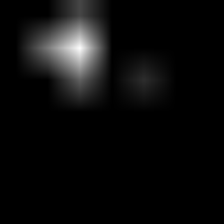

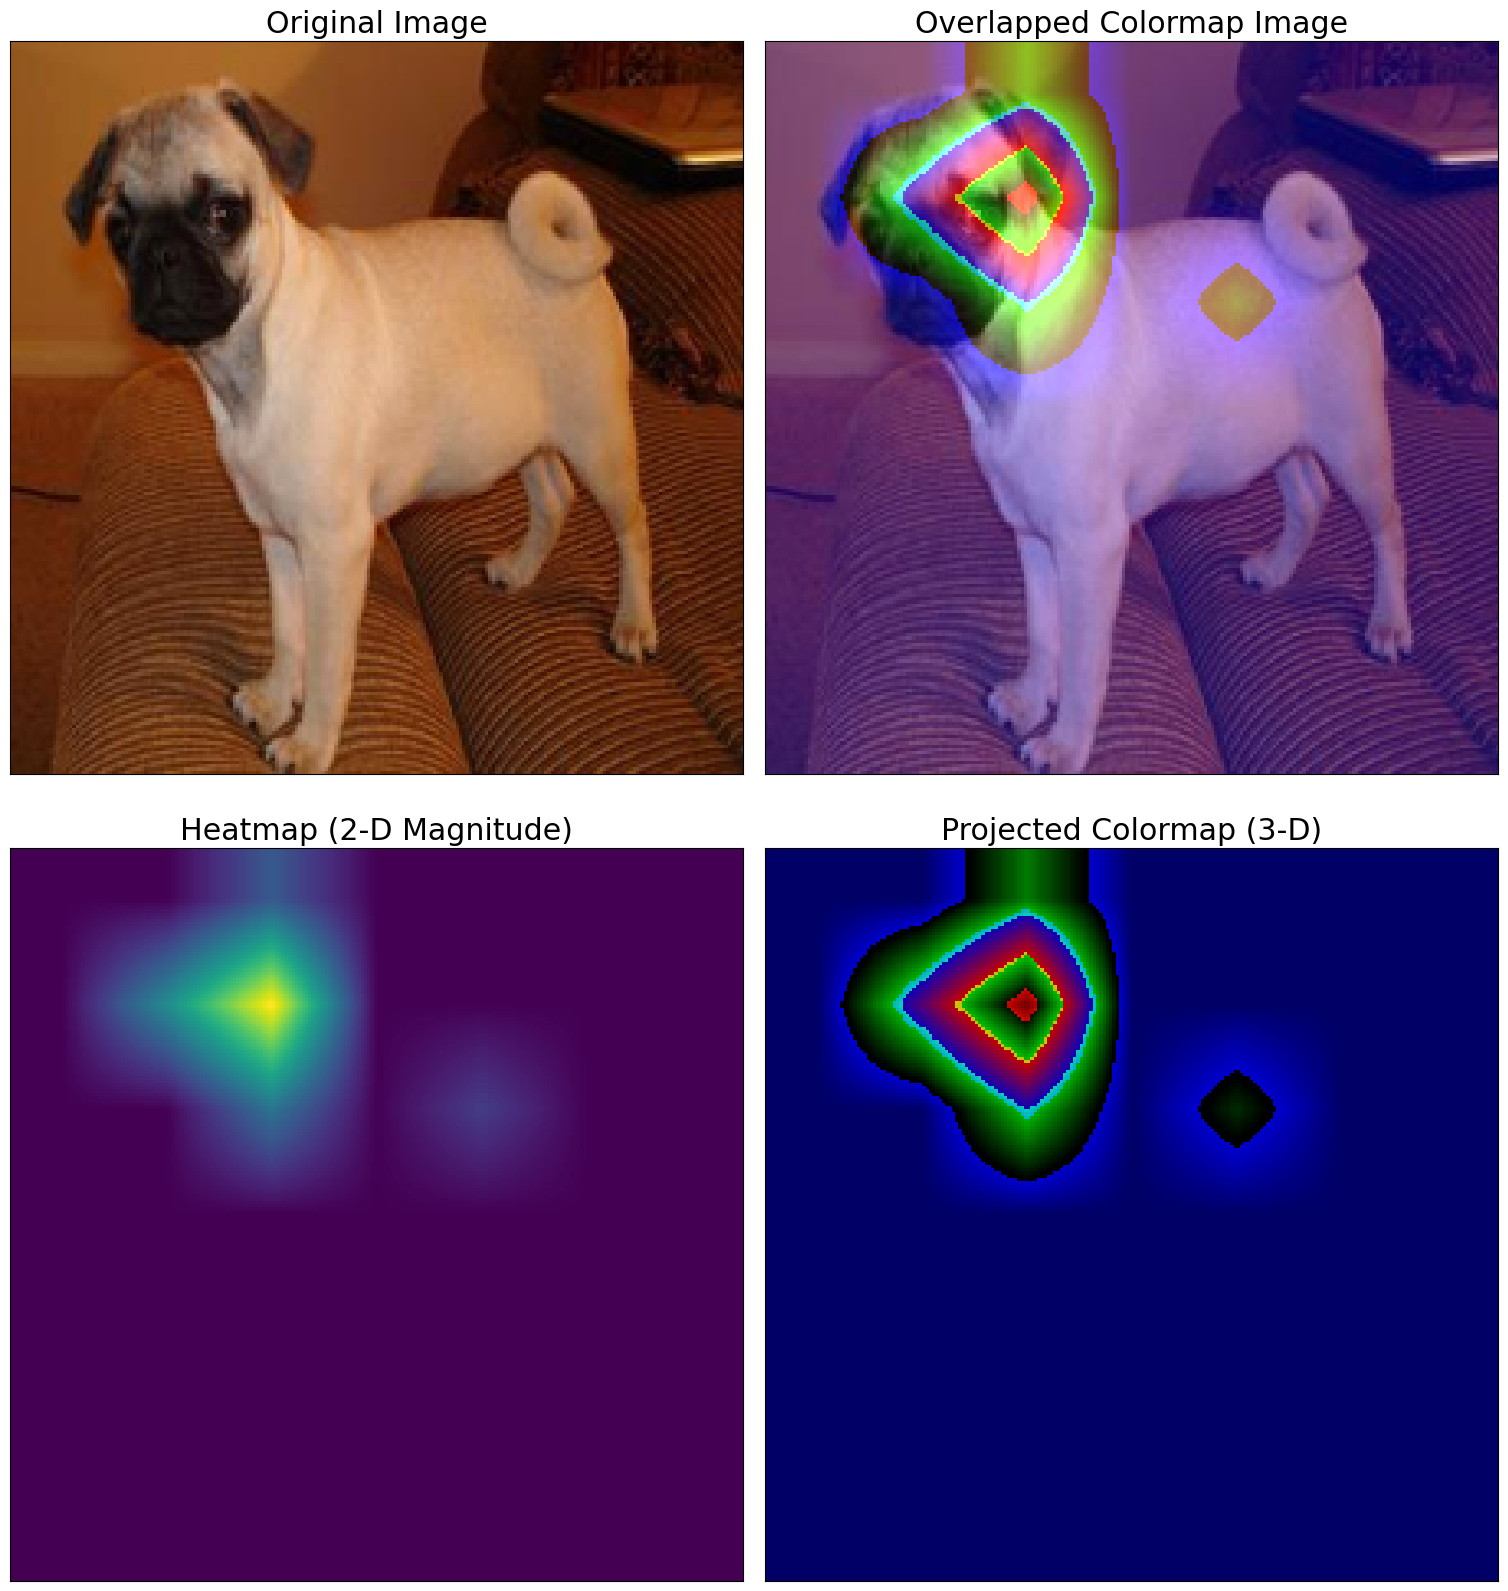

In [2]:
from grad_cam_code.grad_cam import *

#model = create_model('timm/resnet34.a1_in1k', pretrained=True)
model = create_model('timm/resnet18.a1_in1k', pretrained=True)
#model = create_model('timm/resnet10t.c3_in1k', pretrained=True)
model.eval()

## Test image samples are from imagenet
img_path = 'graphs/test_images/test2-pug-dog.png'
#img_path = 'graphs/test_images/test4-hotdog.png'

cam_vit = GradCAM(model,img_path, layer_name='layer4.1.conv2', model_type='Normal', verbose=True)
cam_vit(heatmap_threshold=20)
cam_vit.imposing_visualization(save_path=f'img/ResNet18.png')
cam_vit.heatmap


### Vision Transformer (ViT) model example

#### Apply GradCAM

ViT (-based) is little different from other models, where the GradCAM should be applied to the second last layer [-2], instead of last [-1], since the output head only uses the [:,0,:] first row of the embeddings for the linear projection.

The model types you can select from are either
 'Normal' (CNN based), 'ViT', 'SwinT', 'DeiT', currently is ViT mode.
Use the custom transform you provided to preprocess the image
Output logits shape: torch.Size([1, 1000])
The Grad-CAM will be plotted based on model prediction result: 254 with 85.3% certainty
Activation Shape:torch.Size([1, 197, 768])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.4933621].


gradient shape (predictioin logti(s) w.r.t. feature logits): torch.Size([1, 14, 14, 768])
Shape of weighted Combination between gradients and activations: (14, 14, 768)
Shape after channel summation : (14, 14)
Maximum pixel value of heatmap is 0.009698471985757351
jet_color shape: (256, 3)


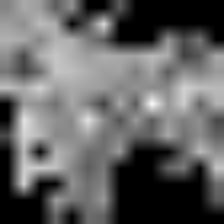

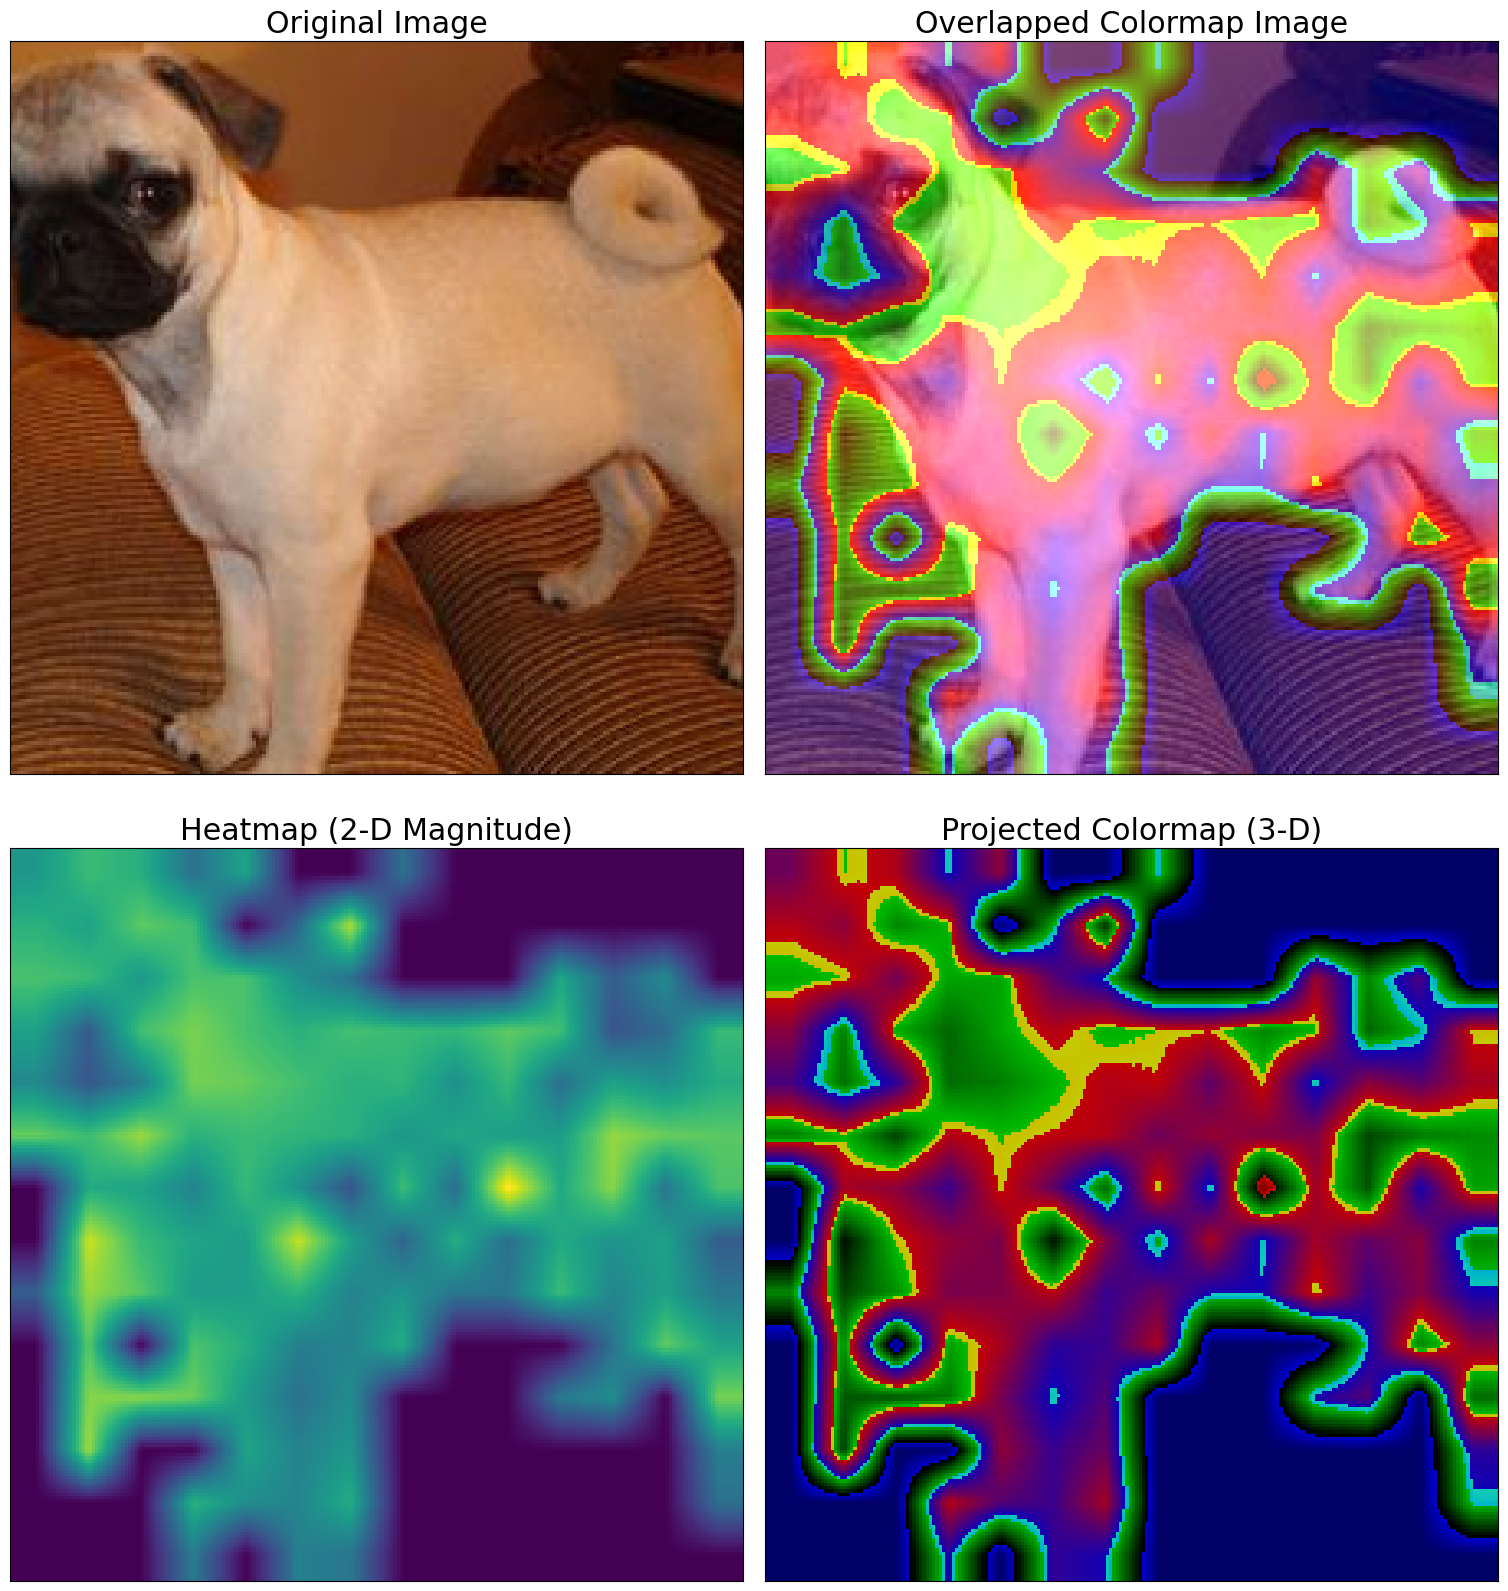

In [8]:
from grad_cam_code.grad_cam import *
from timm.data.transforms_factory import create_transform
from timm.data import resolve_data_config

model = create_model('vit_base_patch16_224', pretrained=True)
## Remember to pass the corresponding preprocessing method, if not using default.
config = resolve_data_config({}, model=model)
transform = create_transform(**config)
model.eval()

## Test image samples are from imagenet
img_path = 'graphs/test_images/test2-pug-dog.png'
#img_path = 'graphs/test_images/test4-hotdog.png'

cam_vit = GradCAM(model,img_path, layer_name='blocks.10.drop_path2', model_type='ViT', transform = transform, verbose=True)
cam_vit(heatmap_threshold=5)
cam_vit.imposing_visualization(save_path=f'img/ViT.png')
cam_vit.heatmap


### DeiT

#### Check layer names for GradCAM visualization

In [4]:
from grad_cam_code.grad_cam import *
model = create_model('timm/deit_small_distilled_patch16_224.fb_in1k', pretrained=True)
print_layername(model)



patch_embed
patch_embed.proj
patch_embed.norm
pos_drop
patch_drop
norm_pre
blocks
blocks.0
blocks.0.norm1
blocks.0.attn
blocks.0.attn.qkv
blocks.0.attn.q_norm
blocks.0.attn.k_norm
blocks.0.attn.attn_drop
blocks.0.attn.proj
blocks.0.attn.proj_drop
blocks.0.ls1
blocks.0.drop_path1
blocks.0.norm2
blocks.0.mlp
blocks.0.mlp.fc1
blocks.0.mlp.act
blocks.0.mlp.drop1
blocks.0.mlp.norm
blocks.0.mlp.fc2
blocks.0.mlp.drop2
blocks.0.ls2
blocks.0.drop_path2
blocks.1
blocks.1.norm1
blocks.1.attn
blocks.1.attn.qkv
blocks.1.attn.q_norm
blocks.1.attn.k_norm
blocks.1.attn.attn_drop
blocks.1.attn.proj
blocks.1.attn.proj_drop
blocks.1.ls1
blocks.1.drop_path1
blocks.1.norm2
blocks.1.mlp
blocks.1.mlp.fc1
blocks.1.mlp.act
blocks.1.mlp.drop1
blocks.1.mlp.norm
blocks.1.mlp.fc2
blocks.1.mlp.drop2
blocks.1.ls2
blocks.1.drop_path2
blocks.2
blocks.2.norm1
blocks.2.attn
blocks.2.attn.qkv
blocks.2.attn.q_norm
blocks.2.attn.k_norm
blocks.2.attn.attn_drop
blocks.2.attn.proj
blocks.2.attn.proj_drop
blocks.2.ls1
blocks.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [2.3305416152474833e-09..1.3866666501820089].


Compose(
    Resize(size=248, interpolation=bicubic, max_size=None, antialias=True)
    CenterCrop(size=(224, 224))
    MaybeToTensor()
    Normalize(mean=tensor([0.4850, 0.4560, 0.4060]), std=tensor([0.2290, 0.2240, 0.2250]))
)
The model types you can select from are either
 'Normal' (CNN based), 'ViT', 'SwinT', 'DeiT', currently is DeiT mode.
Use the custom transform you provided to preprocess the image
Output logits shape: torch.Size([1, 1000])
The Grad-CAM will be plotted based on model prediction result: 254 with 98.8% certainty
Activation Shape:torch.Size([1, 198, 384])
gradient shape (predictioin logti(s) w.r.t. feature logits): torch.Size([1, 14, 14, 384])
Shape of weighted Combination between gradients and activations: (14, 14, 384)
Shape after channel summation : (14, 14)
Maximum pixel value of heatmap is 0.0017595713725313544
jet_color shape: (256, 3)


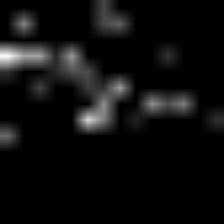

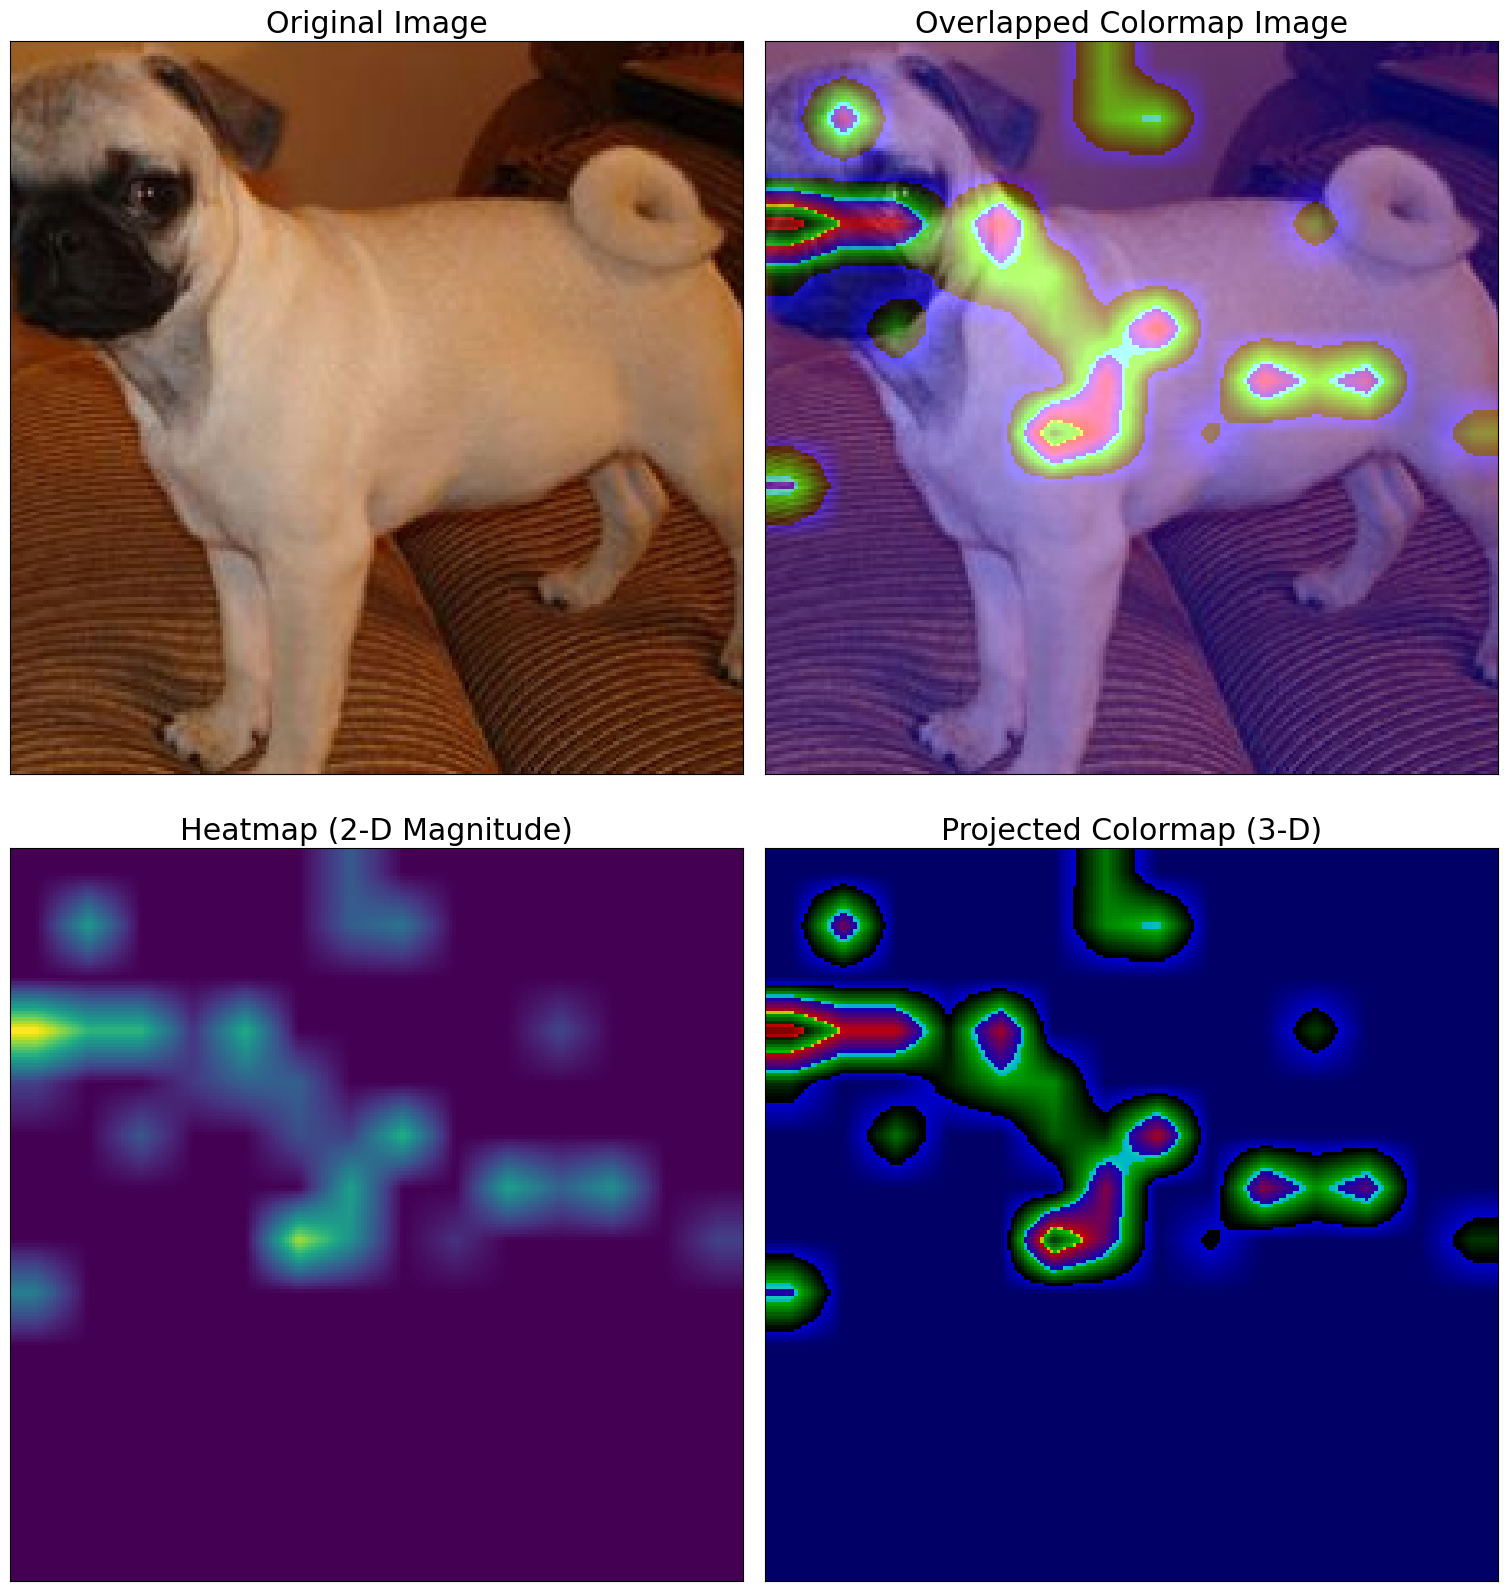

In [9]:
from grad_cam_code.grad_cam import *
from timm.data.transforms_factory import create_transform
from timm.data import resolve_data_config


model = create_model('timm/deit_small_distilled_patch16_224.fb_in1k', pretrained=True)
config = resolve_data_config({}, model=model)
transform = create_transform(**config)
print(transform)
model.eval()

## Test image samples are from imagenet
img_path = 'graphs/test_images/test2-pug-dog.png'
#img_path = 'graphs/test_images/test4-hotdog.png'

cam = GradCAM(model,img_path,layer_name='blocks.10.drop_path2', model_type='DeiT', transform = transform,verbose=True)
cam(heatmap_threshold=8)
cam.imposing_visualization(save_path="img/deit", denormalize=([0.4850, 0.4560, 0.4060],[0.2290, 0.2240, 0.2250]))    #specify the normalization method if not using the default when saving the images
cam.heatmap


## Swin Transformer

#### Check layer names for GradCAM visualization

In [6]:
from grad_cam_code.grad_cam import *
model = create_model('swin_base_patch4_window7_224', pretrained=True)
print_layername(model)


patch_embed
patch_embed.proj
patch_embed.norm
layers
layers.0
layers.0.downsample
layers.0.blocks
layers.0.blocks.0
layers.0.blocks.0.norm1
layers.0.blocks.0.attn
layers.0.blocks.0.attn.qkv
layers.0.blocks.0.attn.attn_drop
layers.0.blocks.0.attn.proj
layers.0.blocks.0.attn.proj_drop
layers.0.blocks.0.attn.softmax
layers.0.blocks.0.drop_path1
layers.0.blocks.0.norm2
layers.0.blocks.0.mlp
layers.0.blocks.0.mlp.fc1
layers.0.blocks.0.mlp.act
layers.0.blocks.0.mlp.drop1
layers.0.blocks.0.mlp.norm
layers.0.blocks.0.mlp.fc2
layers.0.blocks.0.mlp.drop2
layers.0.blocks.0.drop_path2
layers.0.blocks.1
layers.0.blocks.1.norm1
layers.0.blocks.1.attn
layers.0.blocks.1.attn.qkv
layers.0.blocks.1.attn.attn_drop
layers.0.blocks.1.attn.proj
layers.0.blocks.1.attn.proj_drop
layers.0.blocks.1.attn.softmax
layers.0.blocks.1.drop_path1
layers.0.blocks.1.norm2
layers.0.blocks.1.mlp
layers.0.blocks.1.mlp.fc1
layers.0.blocks.1.mlp.act
layers.0.blocks.1.mlp.drop1
layers.0.blocks.1.mlp.norm
layers.0.blocks.1.ml

#### Apply GradCAM

Compose(
    Resize(size=248, interpolation=bicubic, max_size=None, antialias=True)
    CenterCrop(size=(224, 224))
    MaybeToTensor()
    Normalize(mean=tensor([0.4850, 0.4560, 0.4060]), std=tensor([0.2290, 0.2240, 0.2250]))
)
The model types you can select from are either
 'Normal' (CNN based), 'ViT', 'SwinT', 'DeiT', currently is SwinT mode.
Use the custom transform you provided to preprocess the image
Output logits shape: torch.Size([1, 1000])
The Grad-CAM will be plotted based on model prediction result: 254 with 81.5% certainty
Activation Shape:torch.Size([1, 49, 1024])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [2.3305416152474833e-09..1.3866666643838088].


gradient shape (predictioin logti(s) w.r.t. feature logits): torch.Size([1, 7, 7, 1024])
Shape of weighted Combination between gradients and activations: (7, 7, 1024)
Shape after channel summation : (7, 7)
Maximum pixel value of heatmap is 0.12963619828224182
jet_color shape: (256, 3)


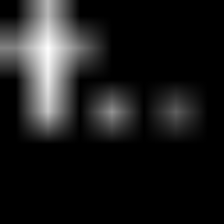

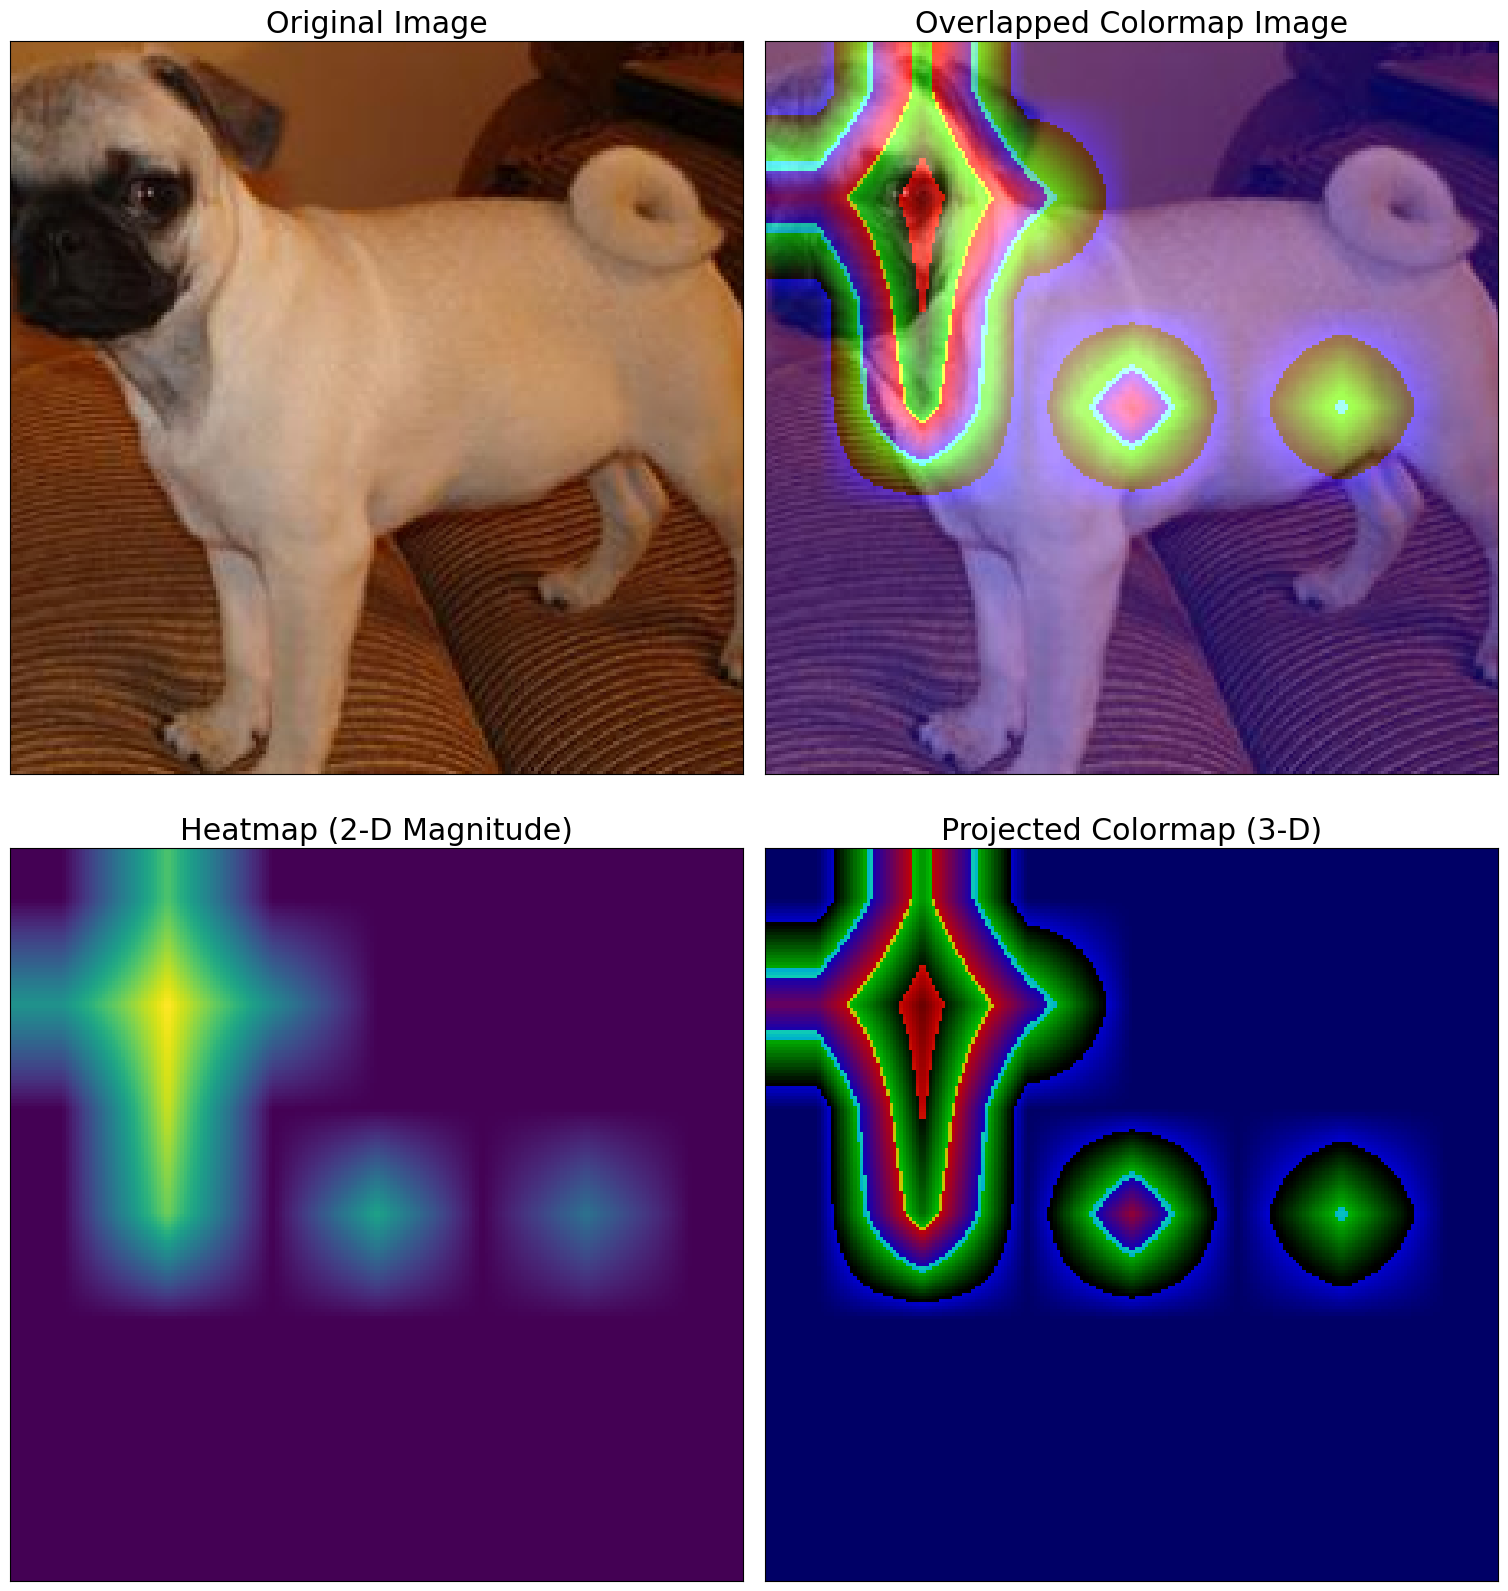

In [7]:
from grad_cam_code.grad_cam import *
from timm.data.transforms_factory import create_transform
from timm.data import resolve_data_config


model = create_model('swin_base_patch4_window7_224', pretrained=True)
config = resolve_data_config({}, model=model)
transform = create_transform(**config)
print(transform)
model.eval()

## Test image samples are from imagenet
img_path = 'graphs/test_images/test2-pug-dog.png'
#img_path = 'graphs/test_images/test4-hotdog.png'

cam = GradCAM(model,img_path,layer_name='layers.3.blocks.1.drop_path2', model_type='SwinT', transform = transform,verbose=True)
cam(heatmap_threshold=40)
cam.imposing_visualization(save_path="img/swt_test", denormalize=([0.4850, 0.4560, 0.4060],[0.2290, 0.2240, 0.2250]))    #specify the normalization method if not using the default when saving the images
cam.heatmap
